In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.datasets import make_classification, make_blobs, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from kmeans import KMeansHandMade

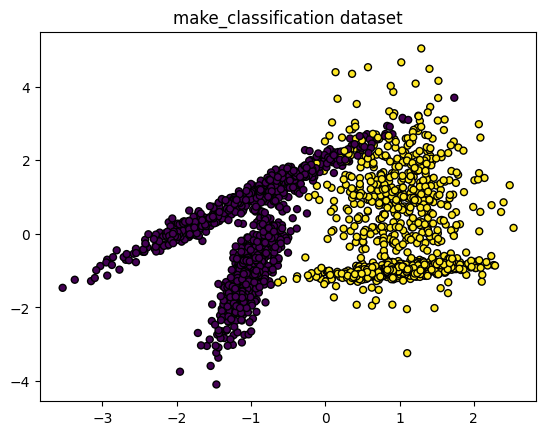

In [180]:
X_class, y_class = make_classification(n_samples=2000, n_classes=2, n_features=2, n_redundant=0, n_clusters_per_class=2, flip_y=0, random_state=110)

plt.scatter(X_class[:, 0], X_class[:, 1], c=y_class,
            marker="o", s=25, edgecolor="k")
plt.title("make_classification dataset")
plt.show()

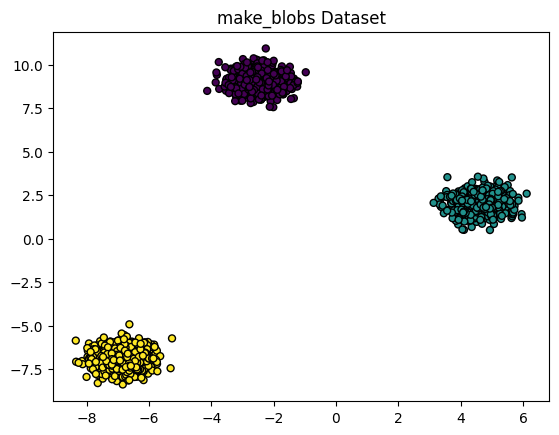

In [181]:
X_blobs, y_blobs = make_blobs(n_samples=2000, n_features=2, centers=3, cluster_std=0.5, random_state=42)

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, marker="o", s=25, edgecolor="k")
plt.title("make_blobs Dataset")
plt.show()

### KMeans

#### make_classification

In [182]:
inertias = []
sil_scores = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_class)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_class, kmeans.labels_))

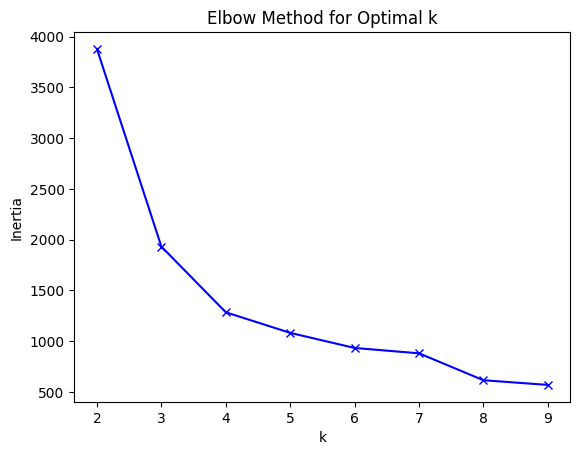

In [183]:
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

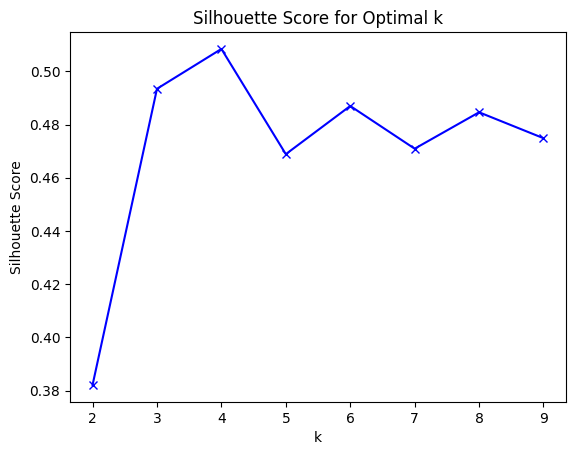

In [184]:
plt.plot(k_range, sil_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

In [185]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_class)
fig = px.scatter(x=X_class[:, 0], y=X_class[:, 1], color=labels_kmeans.astype(
    str), title="K-means Clustering on make_classification")
fig.show()

In [186]:
ari_kmeans = adjusted_rand_score(y_class, labels_kmeans)
nmi_kmeans = normalized_mutual_info_score(y_class, labels_kmeans)
sil_kmeans = silhouette_score(X_class, labels_kmeans)
db_kmeans = davies_bouldin_score(X_class, labels_kmeans)
print(f"K-means on make_classification - ARI: {ari_kmeans}, NMI: {nmi_kmeans}, Silhouette: {sil_kmeans}, DB: {db_kmeans}")

K-means on make_classification - ARI: 0.4073870900075155, NMI: 0.49344130023817856, Silhouette: 0.5084213659310604, DB: 0.6760960688428312


#### make_blobs

In [187]:
inertias = []
sil_scores = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_blobs)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_blobs, kmeans.labels_))

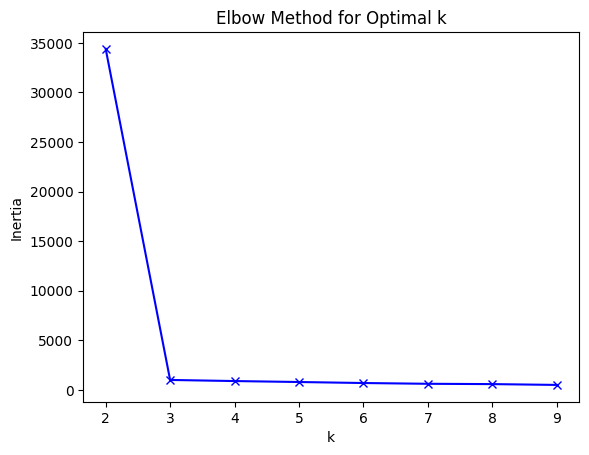

In [188]:
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

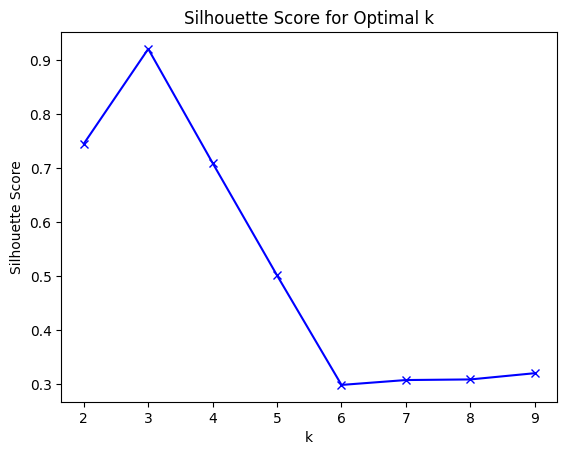

In [189]:
plt.plot(k_range, sil_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

In [190]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_blobs)
fig = px.scatter(x=X_blobs[:, 0], y=X_blobs[:, 1], color=labels_kmeans.astype(
    str), title="K-means Clustering on make_blobs")
fig.show()

In [191]:
ari_kmeans = adjusted_rand_score(y_blobs, labels_kmeans)
nmi_kmeans = normalized_mutual_info_score(y_blobs, labels_kmeans)
sil_kmeans = silhouette_score(X_blobs, labels_kmeans)
db_kmeans = davies_bouldin_score(X_blobs, labels_kmeans)
print(f"K-means on make_blobs - ARI: {ari_kmeans}, NMI: {nmi_kmeans}, Silhouette: {sil_kmeans}, DB: {db_kmeans}")

K-means on make_blobs - ARI: 1.0, NMI: 0.9999999999999998, Silhouette: 0.9210481128970893, DB: 0.11088648928175548


### Иерархическая кластеризация

#### make_classification

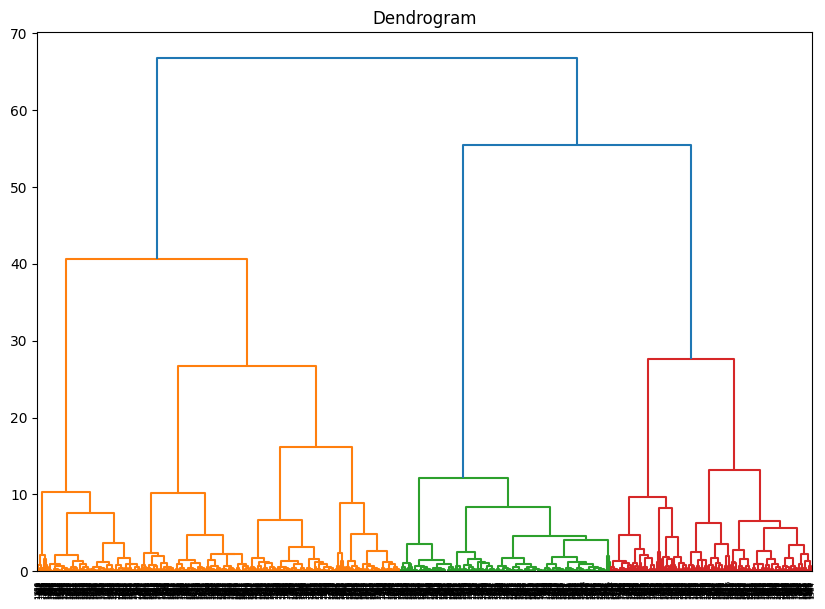

In [192]:
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_class, method='ward'))
plt.title('Dendrogram')
plt.show()

In [193]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hier = hierarchical.fit_predict(X_class)
fig = px.scatter(x=X_class[:,0], y=X_class[:,1], color=labels_hier.astype(str), title="Hierarchical Clustering on make_classification")
fig.show()

In [194]:
ari_hier = adjusted_rand_score(y_class, labels_hier)
nmi_hier = normalized_mutual_info_score(y_class, labels_hier)
sil_hier = silhouette_score(X_class, labels_hier)
db_hier = davies_bouldin_score(X_class, labels_hier)
print(f"Hierarchical on make_classification - ARI: {ari_hier}, NMI: {nmi_hier}, Silhouette: {sil_hier}, DB: {db_hier}")

Hierarchical on make_classification - ARI: 0.6324239294945725, NMI: 0.6319451354780121, Silhouette: 0.42329260562444265, DB: 0.795645737513392


#### make_blobs

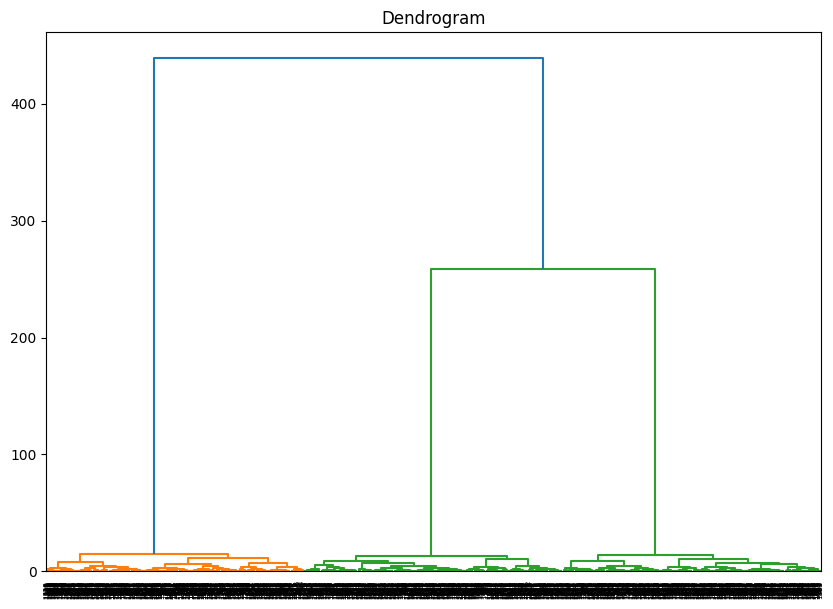

In [195]:
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_blobs, method='ward'))
plt.title('Dendrogram')
plt.show()

In [196]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hier = hierarchical.fit_predict(X_blobs)
fig = px.scatter(x=X_blobs[:,0], y=X_blobs[:,1], color=labels_hier.astype(str), title="Hierarchical Clustering on make_blobs")
fig.show()

In [197]:
ari_hier = adjusted_rand_score(y_blobs, labels_hier)
nmi_hier = normalized_mutual_info_score(y_blobs, labels_hier)
sil_hier = silhouette_score(X_blobs, labels_hier)
db_hier = davies_bouldin_score(X_blobs, labels_hier)
print(f"Hierarchical on make_blobs - ARI: {ari_hier}, NMI: {nmi_hier}, Silhouette: {sil_hier}, DB: {db_hier}")

Hierarchical on make_blobs - ARI: 1.0, NMI: 0.9999999999999998, Silhouette: 0.9210481128970893, DB: 0.11088648928175548


### DBSCAN

#### make_classification

In [198]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_class)
fig = px.scatter(x=X_class[:,0], y=X_class[:,1], color=labels_dbscan.astype(str), title="DBSCAN Clustering on make_classification")
fig.show()

In [199]:
ari_dbscan = adjusted_rand_score(y_class, labels_dbscan)
nmi_dbscan = normalized_mutual_info_score(y_class, labels_dbscan)
sil_dbscan = silhouette_score(X_class, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
db_dbscan = davies_bouldin_score(X_class, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
print(f"DBSCAN on make_blobs - ARI: {ari_dbscan}, NMI: {nmi_dbscan}, Silhouette: {sil_dbscan}, DB: {db_dbscan}")

DBSCAN on make_blobs - ARI: 1.6036161756869696e-05, NMI: 0.0020461801299475574, Silhouette: 0.500696765842896, DB: 3.0626492694799037


#### make_blobs

In [200]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_blobs)
fig = px.scatter(x=X_blobs[:,0], y=X_blobs[:,1], color=labels_dbscan.astype(str), title="DBSCAN Clustering on make_blobs")
fig.show()

In [201]:
ari_dbscan = adjusted_rand_score(y_blobs, labels_dbscan)
nmi_dbscan = normalized_mutual_info_score(y_blobs, labels_dbscan)
sil_dbscan = silhouette_score(X_blobs, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
db_dbscan = davies_bouldin_score(X_blobs, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
print(f"DBSCAN on make_blobs - ARI: {ari_dbscan}, NMI: {nmi_dbscan}, Silhouette: {sil_dbscan}, DB: {db_dbscan}")

DBSCAN on make_blobs - ARI: 0.9969958731571209, NMI: 0.9925827258002348, Silhouette: 0.9049905109294247, DB: 1.062530961270631


### GMM

#### make_classification

In [202]:
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_class)
fig = px.scatter(x=X_class[:,0], y=X_class[:,1], color=labels_gmm.astype(str), title="GMM Clustering on make_classification")
fig.show()

In [203]:
ari_gmm = adjusted_rand_score(y_class, labels_gmm)
nmi_gmm = normalized_mutual_info_score(y_class, labels_gmm)
sil_gmm = silhouette_score(X_class, labels_gmm)
db_gmm = davies_bouldin_score(X_class, labels_gmm)
print(f"GMM on make_classification - ARI: {ari_gmm}, NMI: {nmi_gmm}, Silhouette: {sil_gmm}, DB: {db_gmm}")

GMM on make_classification - ARI: 0.5966236541666443, NMI: 0.6066363230832315, Silhouette: 0.4202488885574807, DB: 0.7981577455965866


#### make_blobs

In [204]:
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_blobs)
fig = px.scatter(x=X_blobs[:,0], y=X_blobs[:,1], color=labels_gmm.astype(str), title="GMM Clustering on make_blobs")
fig.show()

In [205]:
ari_gmm = adjusted_rand_score(y_blobs, labels_gmm)
nmi_gmm = normalized_mutual_info_score(y_blobs, labels_gmm)
sil_gmm = silhouette_score(X_blobs, labels_gmm)
db_gmm = davies_bouldin_score(X_blobs, labels_gmm)
print(f"GMM on make_blobs - ARI: {ari_gmm}, NMI: {nmi_gmm}, Silhouette: {sil_gmm}, DB: {db_gmm}")

GMM on make_blobs - ARI: 1.0, NMI: 0.9999999999999998, Silhouette: 0.9210481128970893, DB: 0.11088648928175548


### Affinity Propagation

#### make_classification

In [206]:
affinity = AffinityPropagation(random_state=42)
labels_affinity = affinity.fit_predict(X_class)
fig = px.scatter(x=X_class[:,0], y=X_class[:,1], color=labels_affinity.astype(str), title="Affinity Propagation on make_classification")
fig.show()

p:\Python\ML1\venv\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning:

Affinity propagation did not converge, this model may return degenerate cluster centers and labels.



In [207]:
ari_affinity = adjusted_rand_score(y_class, labels_affinity)
nmi_affinity = normalized_mutual_info_score(y_class, labels_affinity)
sil_affinity = silhouette_score(X_class, labels_affinity)
db_affinity = davies_bouldin_score(X_class, labels_affinity)
print(f"Affinity Propagation on make_classification - ARI: {ari_affinity}, NMI: {nmi_affinity}, Silhouette: {sil_affinity}, DB: {db_affinity}")

Affinity Propagation on make_classification - ARI: 0.03397196855279193, NMI: 0.23261743643291416, Silhouette: 0.17917133633100052, DB: 0.5153783998412176


#### make_blobs

In [208]:
affinity = AffinityPropagation(random_state=42)
labels_affinity = affinity.fit_predict(X_blobs)
fig = px.scatter(x=X_blobs[:,0], y=X_blobs[:,1], color=labels_affinity.astype(str), title="Affinity Propagation on make_blobs")
fig.show()

p:\Python\ML1\venv\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning:

Affinity propagation did not converge, this model may return degenerate cluster centers and labels.



In [209]:
ari_affinity = adjusted_rand_score(y_blobs, labels_affinity)
nmi_affinity = normalized_mutual_info_score(y_blobs, labels_affinity)
sil_affinity = silhouette_score(X_blobs, labels_affinity)
db_affinity = davies_bouldin_score(X_blobs, labels_affinity)
print(f"Affinity Propagation on make_blobs - ARI: {ari_affinity}, NMI: {nmi_affinity}, Silhouette: {sil_affinity}, DB: {db_affinity}")

Affinity Propagation on make_blobs - ARI: 0.004451939225336981, NMI: 0.2656015800309451, Silhouette: 0.02076909967398111, DB: 0.3268565318797745


# K4

In [210]:
data = pd.read_csv("data/k4_balanced.csv").head(2000)

In [211]:
X = data.drop("Fire Alarm", axis=1)
y = data["Fire Alarm"]

In [212]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [213]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### K-means

In [214]:
inertias = []
sil_scores = []
k_range = range(2, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

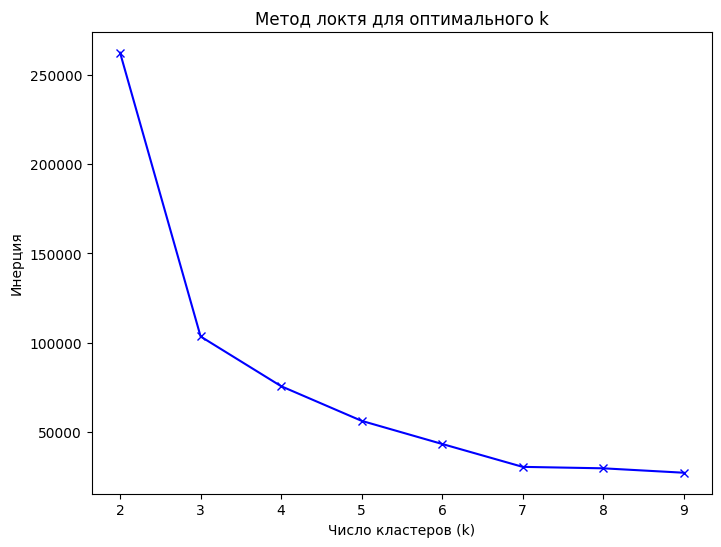

In [215]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Инерция')
plt.title('Метод локтя для оптимального k')
plt.show()

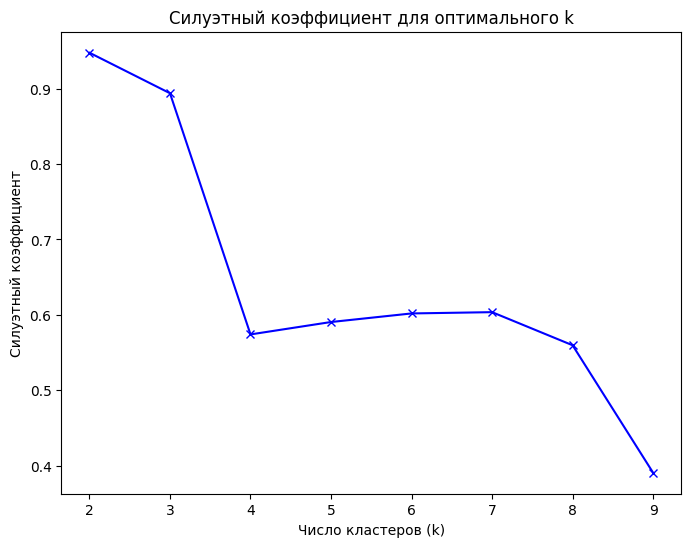

In [216]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, sil_scores, 'bx-')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Силуэтный коэффициент для оптимального k')
plt.show()

In [217]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

### DBSCAN

In [218]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

In [219]:
fig_dbscan = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels_dbscan.astype(str),
                        title="DBSCAN кластеризация (данные после PCA)",
                        labels={'x': 'PC1', 'y': 'PC2'})
fig_dbscan.show()

### EM-алгоритм

In [220]:
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

In [221]:
fig_gmm = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels_gmm.astype(str),
                     title="GMM кластеризация (данные после PCA)",
                     labels={'x': 'PC1', 'y': 'PC2'})
fig_gmm.show()

### Affinity Propagation

In [222]:
affinity = AffinityPropagation(random_state=42)
labels_affinity = affinity.fit_predict(X_scaled)

p:\Python\ML1\venv\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:142: ConvergenceWarning:

Affinity propagation did not converge, this model may return degenerate cluster centers and labels.



In [223]:
fig_affinity = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels_affinity.astype(str),
                          title="Affinity Propagation кластеризация (данные после PCA)",
                          labels={'x': 'PC1', 'y': 'PC2'})
fig_affinity.show()

In [224]:
data_with_clusters = data.copy()
data_with_clusters['Cluster_Kmeans'] = labels_kmeans
data_with_clusters['Cluster_DBSCAN'] = labels_dbscan
data_with_clusters['Cluster_GMM'] = labels_gmm
data_with_clusters['Cluster_Affinity'] = labels_affinity

In [225]:
cluster_stats_kmeans = data_with_clusters.groupby('Cluster_Kmeans').mean()
print("Характеристики кластеров для K-means:")
print(cluster_stats_kmeans)

Характеристики кластеров для K-means:
                         UTC  Temperature[C]  Humidity[%]    TVOC[ppb]  \
Cluster_Kmeans                                                           
0               1.654840e+09       30.563100    25.602025  1075.248482   
1               1.654927e+09       22.332068    24.957217   958.893147   
2               1.654808e+09       17.599726    47.243364   564.165556   

                  eCO2[ppm]       Raw H2   Raw Ethanol  Pressure[hPa]  \
Cluster_Kmeans                                                          
0                765.789939  12350.50000  18766.200000     936.211488   
1               3635.097005  12130.50000  18508.875000     934.278782   
2                447.037408  12933.72695  19886.403242     938.481115   

                   PM1.0     PM2.5      NC0.5     NC1.0     NC2.5  Fire Alarm  \
Cluster_Kmeans                                                                  
0               0.979098  1.005168   4.734210  1.331787  1.7277

### Внешние метрики

In [226]:
ari_kmeans = adjusted_rand_score(y, labels_kmeans)
nmi_kmeans = normalized_mutual_info_score(y, labels_kmeans)
ari_dbscan = adjusted_rand_score(y, labels_dbscan)
nmi_dbscan = normalized_mutual_info_score(y, labels_dbscan)
ari_gmm = adjusted_rand_score(y, labels_gmm)
nmi_gmm = normalized_mutual_info_score(y, labels_gmm)
ari_affinity = adjusted_rand_score(y, labels_affinity)
nmi_affinity = normalized_mutual_info_score(y, labels_affinity)

### Внутренние метрики

In [227]:
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)
sil_dbscan = silhouette_score(X_scaled, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
db_dbscan = davies_bouldin_score(X_scaled, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1
sil_gmm = silhouette_score(X_scaled, labels_gmm)
db_gmm = davies_bouldin_score(X_scaled, labels_gmm)
sil_affinity = silhouette_score(X_scaled, labels_affinity)
db_affinity = davies_bouldin_score(X_scaled, labels_affinity)

Вывод метрик

In [228]:
print("\nМетрики оценки кластеризации:")
print(f"K-means - ARI: {ari_kmeans:.3f}, NMI: {nmi_kmeans:.3f}, Силуэт: {sil_kmeans:.3f}, DB индекс: {db_kmeans:.3f}")
print(f"DBSCAN - ARI: {ari_dbscan:.3f}, NMI: {nmi_dbscan:.3f}, Силуэт: {sil_dbscan:.3f}, DB индекс: {db_dbscan:.3f}")
print(f"GMM - ARI: {ari_gmm:.3f}, NMI: {nmi_gmm:.3f}, Силуэт: {sil_gmm:.3f}, DB индекс: {db_gmm:.3f}")
print(f"Affinity Propagation - ARI: {ari_affinity:.3f}, NMI: {nmi_affinity:.3f}, Силуэт: {sil_affinity:.3f}, DB индекс: {db_affinity:.3f}")


Метрики оценки кластеризации:
K-means - ARI: 0.000, NMI: 0.004, Силуэт: 0.894, DB индекс: 0.658
DBSCAN - ARI: 0.081, NMI: 0.271, Силуэт: 0.077, DB индекс: 2.217
GMM - ARI: 0.000, NMI: 0.003, Силуэт: 0.893, DB индекс: 0.702
Affinity Propagation - ARI: 0.053, NMI: 0.282, Силуэт: 0.329, DB индекс: 0.664


### Сохранение датасета с новым столбцом

In [229]:
kmeans = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

In [230]:
data.to_csv("data/k4_balanced_with_clusters.csv", index=False)

### k-means очумелые ручки

In [262]:
def apply_kmeans(X, n_clusters=3):
    custom_kmeans = KMeansHandMade(n_clusters=n_clusters, random_state=42)
    custom_kmeans.fit(X)
    sk_kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    sk_kmeans.fit(X)
    return custom_kmeans, sk_kmeans

In [263]:
custom_blobs, sk_blobs = apply_kmeans(X_blobs)
custom_class, sk_class = apply_kmeans(X_class)
custom_iris, sk_iris = apply_kmeans(X_pca)

In [264]:
def visualize_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    fig = px.scatter(x=X_2d[:, 0], y=X_2d[:, 1], color=labels.astype(str), title=title)
    fig.show()

In [265]:
visualize_clusters(X_blobs, custom_blobs.labels_, "Custom K-means на make_blobs")
visualize_clusters(X_blobs, sk_blobs.labels_, "Scikit-learn K-means на make_blobs")
visualize_clusters(X_class, custom_class.labels_, "Custom K-means на make_classification")
visualize_clusters(X_class, sk_class.labels_, "Scikit-learn K-means на make_classification")
visualize_clusters(X_pca, custom_iris.labels_, "Custom K-means на k4")
visualize_clusters(X_pca, sk_iris.labels_, "Scikit-learn K-means на k4")

In [266]:
def evaluate_clustering(X, labels, y_true=None):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else None
    nmi = normalized_mutual_info_score(y_true, labels) if y_true is not None else None
    return sil, db, ari, nmi

In [267]:
results = []
for name, X, custom, sk, y in [
    ("make_blobs", X_blobs, custom_blobs, sk_blobs, y_blobs),
    ("make_classification", X_class, custom_class, sk_class, y_class),
    ("Iris", X_pca, custom_iris, sk_iris, y)
]:
    sil_c, db_c, ari_c, nmi_c = evaluate_clustering(X, custom.labels_, y)
    sil_s, db_s, ari_s, nmi_s = evaluate_clustering(X, sk.labels_, y)
    results.append({
        "Dataset": name,
        "Method": "Custom",
        "Inertia": custom.inertia_,
        "Silhouette": sil_c,
        "Davies-Bouldin": db_c,
        "ARI": ari_c,
        "NMI": nmi_c
    })
    results.append({
        "Dataset": name,
        "Method": "Scikit-learn",
        "Inertia": sk.inertia_,
        "Silhouette": sil_s,
        "Davies-Bouldin": db_s,
        "ARI": ari_s,
        "NMI": nmi_s
    })

In [268]:
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

| Dataset             | Method       |   Inertia |   Silhouette |   Davies-Bouldin |         ARI |        NMI |
|:--------------------|:-------------|----------:|-------------:|-----------------:|------------:|-----------:|
| make_blobs          | Custom       |   993.154 |     0.921048 |         0.110886 | 1           | 1          |
| make_blobs          | Scikit-learn |   993.154 |     0.921048 |         0.110886 | 1           | 1          |
| make_classification | Custom       |  1932.48  |     0.493557 |         0.700996 | 0.482749    | 0.520767   |
| make_classification | Scikit-learn |  1932.54  |     0.493441 |         0.700953 | 0.480892    | 0.519622   |
| Iris                | Custom       | 70082.7   |     0.943408 |         0.627374 | 0.000228113 | 0.00413703 |
| Iris                | Scikit-learn | 70082.7   |     0.943408 |         0.627374 | 0.000228113 | 0.00413703 |
